# **Spotify Music Reommendation System**

1. Importing Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2. Loading the datset

In [42]:
df=pd.read_csv("/content/dataset.csv")

In [43]:
display(df.head())

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


3. Dataset Info

In [44]:
df.shape

(114000, 21)

In [45]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [46]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


4. Data Cleaning

In [47]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [48]:
df = df.dropna()

In [49]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [50]:
df.duplicated().sum()

np.int64(0)

5. Exploratory Data Analysis

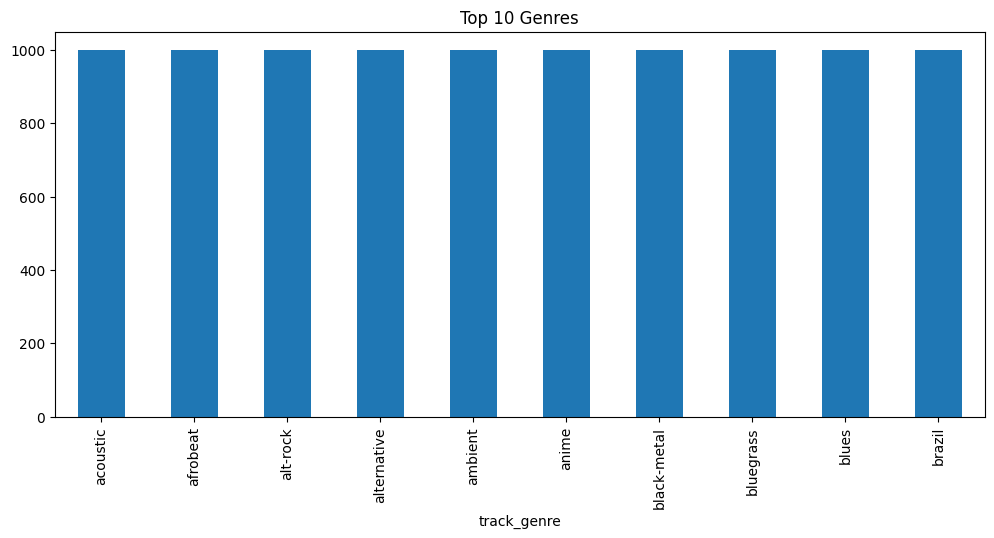

In [51]:
plt.figure(figsize=(12,5))

df["track_genre"].value_counts()[:10].plot(
kind="bar"
)

plt.title(
"Top 10 Genres"
)

plt.show()

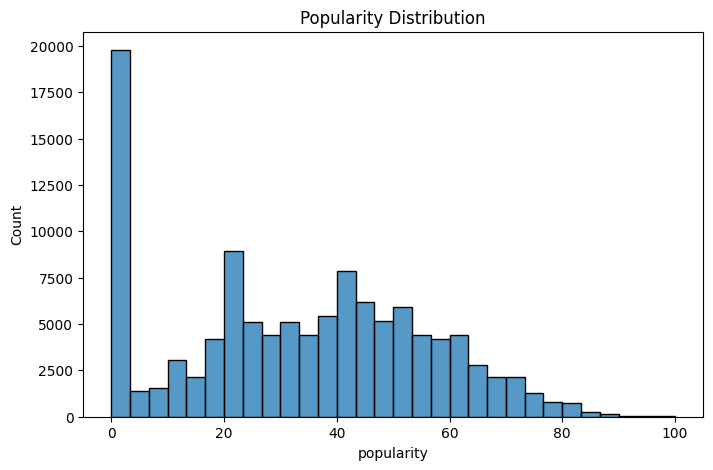

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
df["popularity"],
bins=30
)

plt.title(
"Popularity Distribution"
)

plt.show()

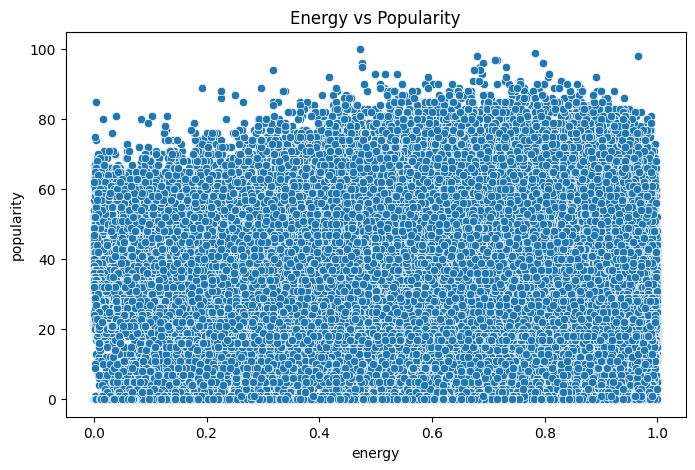

In [53]:
plt.figure(figsize=(8,5))

sns.scatterplot(
data=df,
x="energy",
y="popularity"
)

plt.title(
"Energy vs Popularity"
)

plt.show()

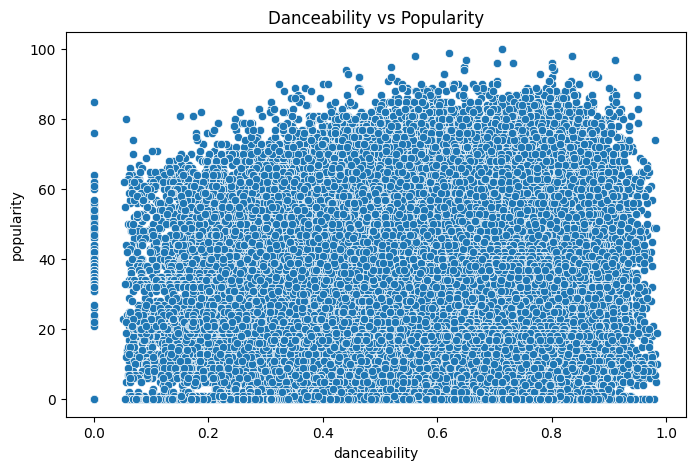

In [54]:
plt.figure(figsize=(8,5))


sns.scatterplot(
data=df,
x="danceability",
y="popularity"
)


plt.title(
"Danceability vs Popularity"
)

plt.show()

6. Feature Selection

In [55]:
songs = df[
[
"artists",
"track_name",
"album_name",
"track_genre",

"danceability",
"energy",
"valence",
"acousticness",
"instrumentalness",
"liveness",
"loudness",
"speechiness",
"tempo",
"popularity",
"explicit"

]
]


songs.head()

,artists,track_name,album_name,track_genre,danceability,energy,valence,acousticness,instrumentalness,liveness,loudness,speechiness,tempo,popularity,explicit
0,Gen Hoshino,Comedy,Comedy,acoustic,0.676,0.4610,0.715,0.0322,0.000001,0.3580,-6.746,0.1430,87.917,73,False
1,Ben Woodward,Ghost - Acoustic,Ghost (Acoustic),acoustic,0.420,0.1660,0.267,0.9240,0.000006,0.1010,-17.235,0.0763,77.489,55,False
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,acoustic,0.438,0.3590,0.120,0.2100,0.000000,0.1170,-9.734,0.0557,76.332,57,False
3,Kina Grannis,Can't Help Falling In Love,Crazy Rich Asians (Original Motion Picture Sou...,acoustic,0.266,0.0596,0.143,0.9050,0.000071,0.1320,-18.515,0.0363,181.740,71,False
4,Chord Overstreet,Hold On,Hold On,acoustic,0.618,0.4430,0.167,0.4690,0.000000,0.0829,-9.681,0.0526,119.949,82,False


7. Convert Explicit

In [56]:
songs["explicit"] = songs["explicit"].astype(int)

8. Creating Combined Fearures

In [57]:
songs["combined"] = (
songs["artists"]+" "+
songs["track_genre"]+" "+
songs["album_name"]
)

9. Performing Text Vectorization

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(
stop_words="english"
)


text_features = tfidf.fit_transform(
songs["combined"]
)

10. Scaling the Audio Features

In [59]:
from sklearn.preprocessing import StandardScaler


audio_features = songs[
[
"danceability",
"energy",
"valence",
"acousticness",
"instrumentalness",
"liveness",
"loudness",
"speechiness",
"tempo",
"explicit"
]
]


scaler = StandardScaler()


scaled_audio = scaler.fit_transform(
audio_features
)

11. Combining Features

In [60]:
from scipy.sparse import hstack

final_features = hstack(
[
text_features,
scaled_audio
]
).tocsr()

12. Similarity Model

In [61]:
from sklearn.neighbors import NearestNeighbors


model = NearestNeighbors(
    n_neighbors=4,
    metric="cosine",
    algorithm="brute"
)


model.fit(
    final_features
)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=4)

In [62]:
print(f"Shape of final_features: {final_features.shape}")
print(f"Type of final_features: {type(final_features)}")
print(f"Number of non-zero elements in final_features: {final_features.nnz}")

Shape of final_features: (113999, 54359)
Type of final_features: <class 'scipy.sparse._csr.csr_matrix'>
Number of non-zero elements in final_features: 1829841


13. Recommendation Function

In [63]:
def recommend(song_name):

    index = songs[
        songs["track_name"] == song_name
    ].index[0]


    distances, indices = model.kneighbors(
        final_features[index]
    )


    result=[]


    for distance, i in zip(distances[0][1:], indices[0][1:]):

        if distance < 0.35:

            result.append(
            {
            "Song":songs.iloc[i]["track_name"],
            "Artist":songs.iloc[i]["artists"],
            "Genre":songs.iloc[i]["track_genre"],
            "Similarity":round(1-distance,2)
            }
            )


    return pd.DataFrame(result)

In [66]:
recommend("I'm Yours")

,Song,Artist,Genre,Similarity
0,I'm Yours,Jason Mraz,acoustic,1.00
1,I'm Yours,Jason Mraz,rock,0.99
2,I'm Yours,Jason Mraz,acoustic,0.93


14. Saving the Model

In [67]:
import pickle


pickle.dump(
songs,
open(
"songs.pkl",
"wb"
)
)


pickle.dump(
model,
open(
"model.pkl",
"wb"
)
)


pickle.dump(
final_features,
open(
"features.pkl",
"wb"
)
)